In [1]:
import sys
sys.path.insert(1, '../')

In [17]:
import joblib
import pickle

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import auc, average_precision_score, precision_recall_curve

from functions.data import load_dataset
from functions.evaluation import roc_curve_imbalanced

In [13]:
import warnings
warnings.filterwarnings("ignore", message="X does not have valid feature names")
warnings.filterwarnings("ignore", message="The total space of parameters")
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)


## Load results

In [4]:
filename = '../models/classical/results'
with open(filename, 'rb') as f:
    scores_dict = pickle.load(f)

In [5]:
def create_df(dataset):
    df = pd.DataFrame(
      scores_dict[dataset],
      index = ["roc", "roc_std", "ap", "ap_std", "precision", "precision_std",
               "recall", "recall_std", "thresh", "tresh_std"],
    )
    df = df.T

    models = [
      "rf", "ada", "gbm", "cat", "lgbm", "xgb",
      ]
    return df.loc[models]

In [6]:
df = create_df("oil")
df.shape

(6, 10)

In [7]:
# test function
df = create_df("arrhythmia")
df

,roc,roc_std,ap,ap_std,precision,precision_std,recall,recall_std,thresh,tresh_std
rf,0.886705,0.012401,0.52716,0.012711,0.811111,0.129577,1.0,0.0,0.282014,0.013808
ada,0.891934,0.010745,0.52716,0.012711,0.837778,0.109228,1.0,0.0,0.534821,0.015149
gbm,0.881725,0.020916,0.52716,0.012711,0.811111,0.129577,1.0,0.0,0.157332,0.013685
cat,0.891934,0.010745,0.52716,0.012711,1.000000,0.000000,1.0,0.0,0.731250,0.086062
lgbm,0.888087,0.013453,0.52716,0.012711,0.782778,0.235390,1.0,0.0,0.726554,0.216408
xgb,0.890668,0.012358,0.52716,0.012711,0.782778,0.235390,1.0,0.0,0.465703,0.108234


## Datasets

In [8]:
scores_dict.keys()

dict_keys(['abalone_19', 'arrhythmia', 'car_eval_4', 'coil_2000', 'ecoli', 'isolet', 'letter_img', 'libras_move', 'mammography', 'oil', 'optical_digits', 'ozone_level', 'pen_digits', 'protein_homo', 'satimage', 'scene', 'sick_euthyroid', 'solar_flare_m0', 'spectrometer', 'thyroid_sick', 'us_crime', 'webpage', 'wine_quality', 'yeast_me2', 'cleveland-0_vs_4', 'dermatology-6', 'glass-0-1-4-6_vs_2', 'kddcup-buffer_overflow_vs_back', 'kr-vs-k-one_vs_fifteen', 'led7digit-0-2-4-5-6-7-8-9_vs_1', 'page-blocks-1-3_vs_4', 'pima', 'poker-8-9_vs_5', 'shuttle-2_vs_5'])

In [9]:
# the number of datasets analysed
len(scores_dict.keys())

34

## Plot ROC-AUC

In [10]:
def compute_ylim(means, stds, upper, lower, target_fraction=0.28):
    """
    Compute y-axis limits so the RF band (upper - lower) occupies
    approximately target_fraction of the total plot height (between 1/4 and 1/3).
    The axis is always wide enough to show all data points with their error bars.
    """
    band_height = upper - lower
    data_min = (means - stds).min()
    data_max = (means + stds).max()
    data_span = data_max - data_min

    if band_height > 0:
        target_height = band_height / target_fraction
    else:
        target_height = max(data_span * 1.2, 0.01)

    height = max(target_height, data_span * 1.1)
    center = (data_min + data_max) / 2
    return center - height / 2, center + height / 2

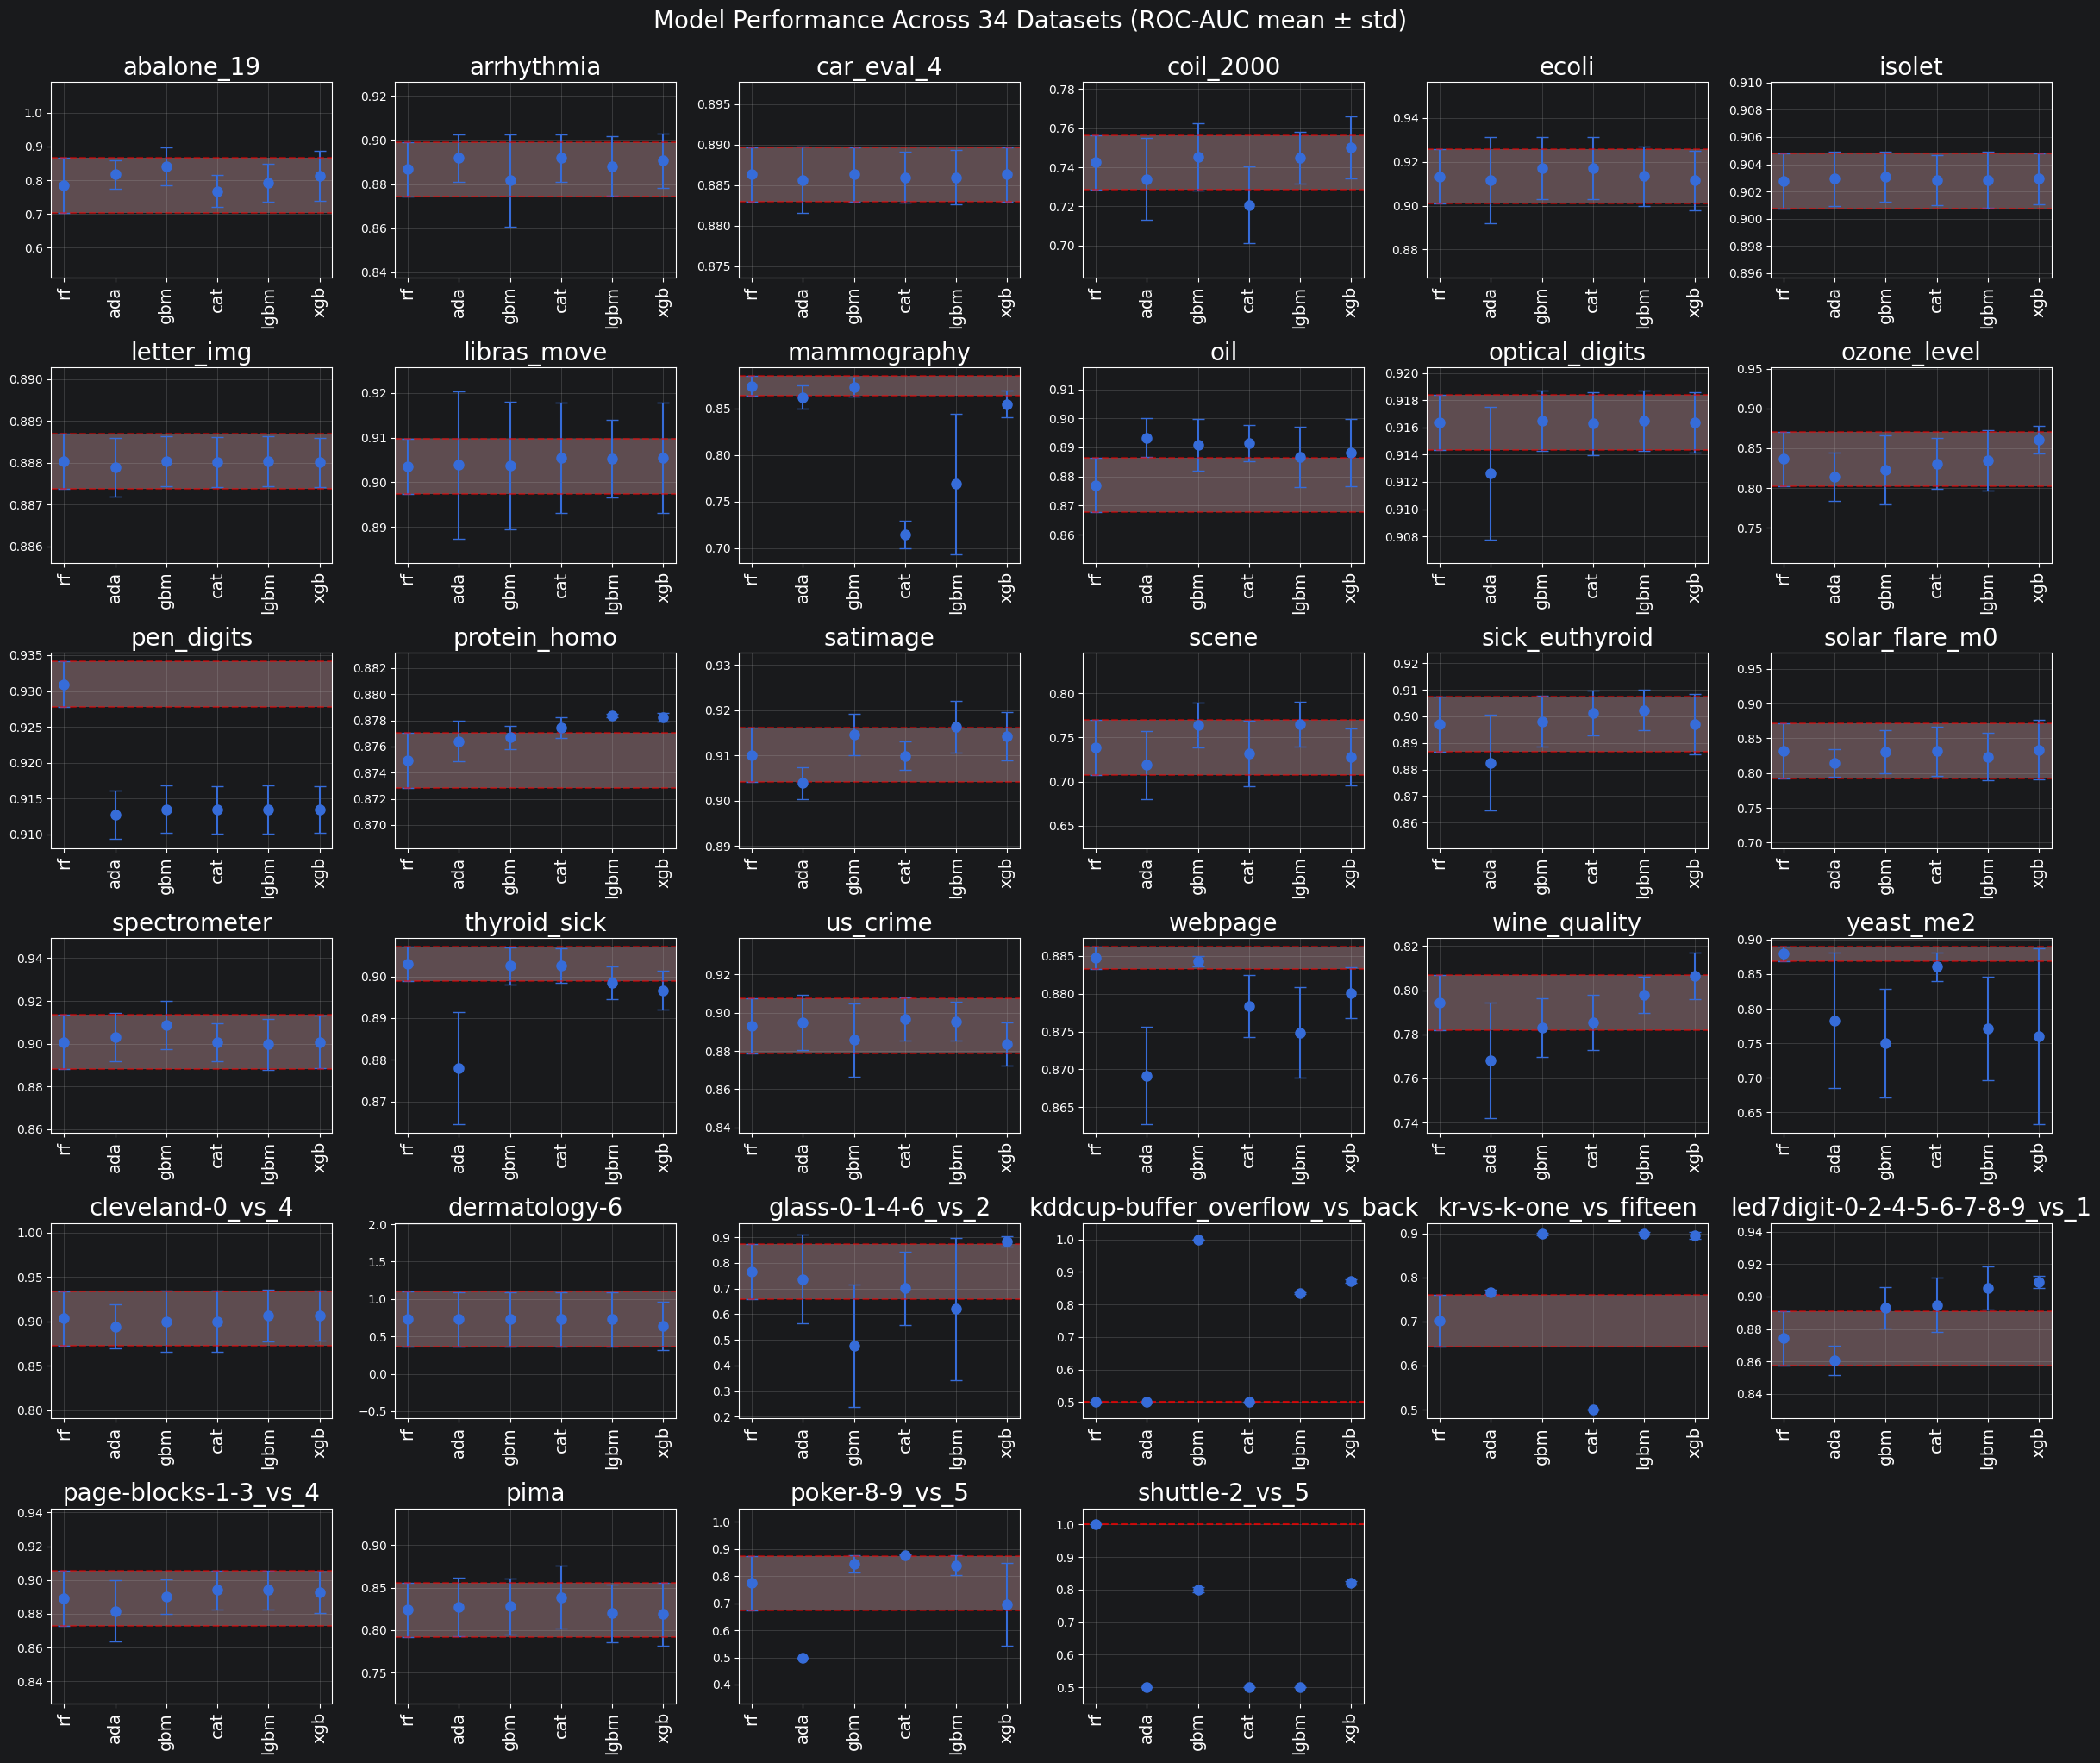

In [11]:
# Create figure with 34 subplots
fig, axes = plt.subplots(nrows=6, ncols=6, figsize=(24, 20))  # 6x6 grid for 34 plots (with 2 empty)
axes = axes.ravel()  # Flatten for easy iteration

# Loop through each DataFrame
for i, data in enumerate(scores_dict.keys()):
    df = create_df(data)

    ax = axes[i]

    # Extract data
    cls = df.index
    means = df.iloc[:, 0]
    stds = df.iloc[:, 1]

    ref = df.iloc[0, 0]
    upper = df.iloc[0, 0] + df.iloc[0, 1]
    lower = df.iloc[0, 0] - df.iloc[0, 1]

    # Create errorbar plot
    ax.errorbar(x=cls, y=means, yerr=stds,
               fmt='o', capsize=5, markersize=8)

    # Customize subplot
    ax.set_title(data, fontsize=20)
    ylims = compute_ylim(means, stds, upper, lower)
    ax.set_ylim(ylims)
    ax.tick_params(axis='x', rotation=90, labelsize=14)
    ax.grid(True, alpha=0.3)

    # Add horizontal lines at random forest error bars
    ax.axhline(y=upper, color='r', linestyle='--', alpha=0.5)
    ax.axhline(y=lower, color='r', linestyle='--', alpha=0.5)

    # color between RF error bars
    ax.axhspan(ymin=lower, ymax=upper, facecolor='pink', alpha=0.3)

# Hide unused subplotsc
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.suptitle('Model Performance Across 34 Datasets (ROC-AUC mean ± std)', fontsize=20, y=1.02)
plt.savefig('../figures/classic_rocauc.png', dpi=300, bbox_inches='tight')
plt.show()

## Plot ROC curves

/Users/soledadgalli/Documents/repositories/env/undersampling/lib/python3.14/site-packages/feature_engine/variable_handling/_variable_type_checks.py:34: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  var = pd.to_datetime(column, utc=True)
/Users/soledadgalli/Documents/repositories/env/undersampling/lib/python3.14/site-packages/feature_engine/variable_handling/_variable_type_checks.py:34: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  var = pd.to_datetime(column, utc=True)
/Users/soledadgalli/Documents/repositories/env/undersampling/lib/python3.14/site-packages/feature_engine/variable_handling/_variable_type_checks.py:34: UserWarning: Could not infer format, so each element will be parsed individually, falling back

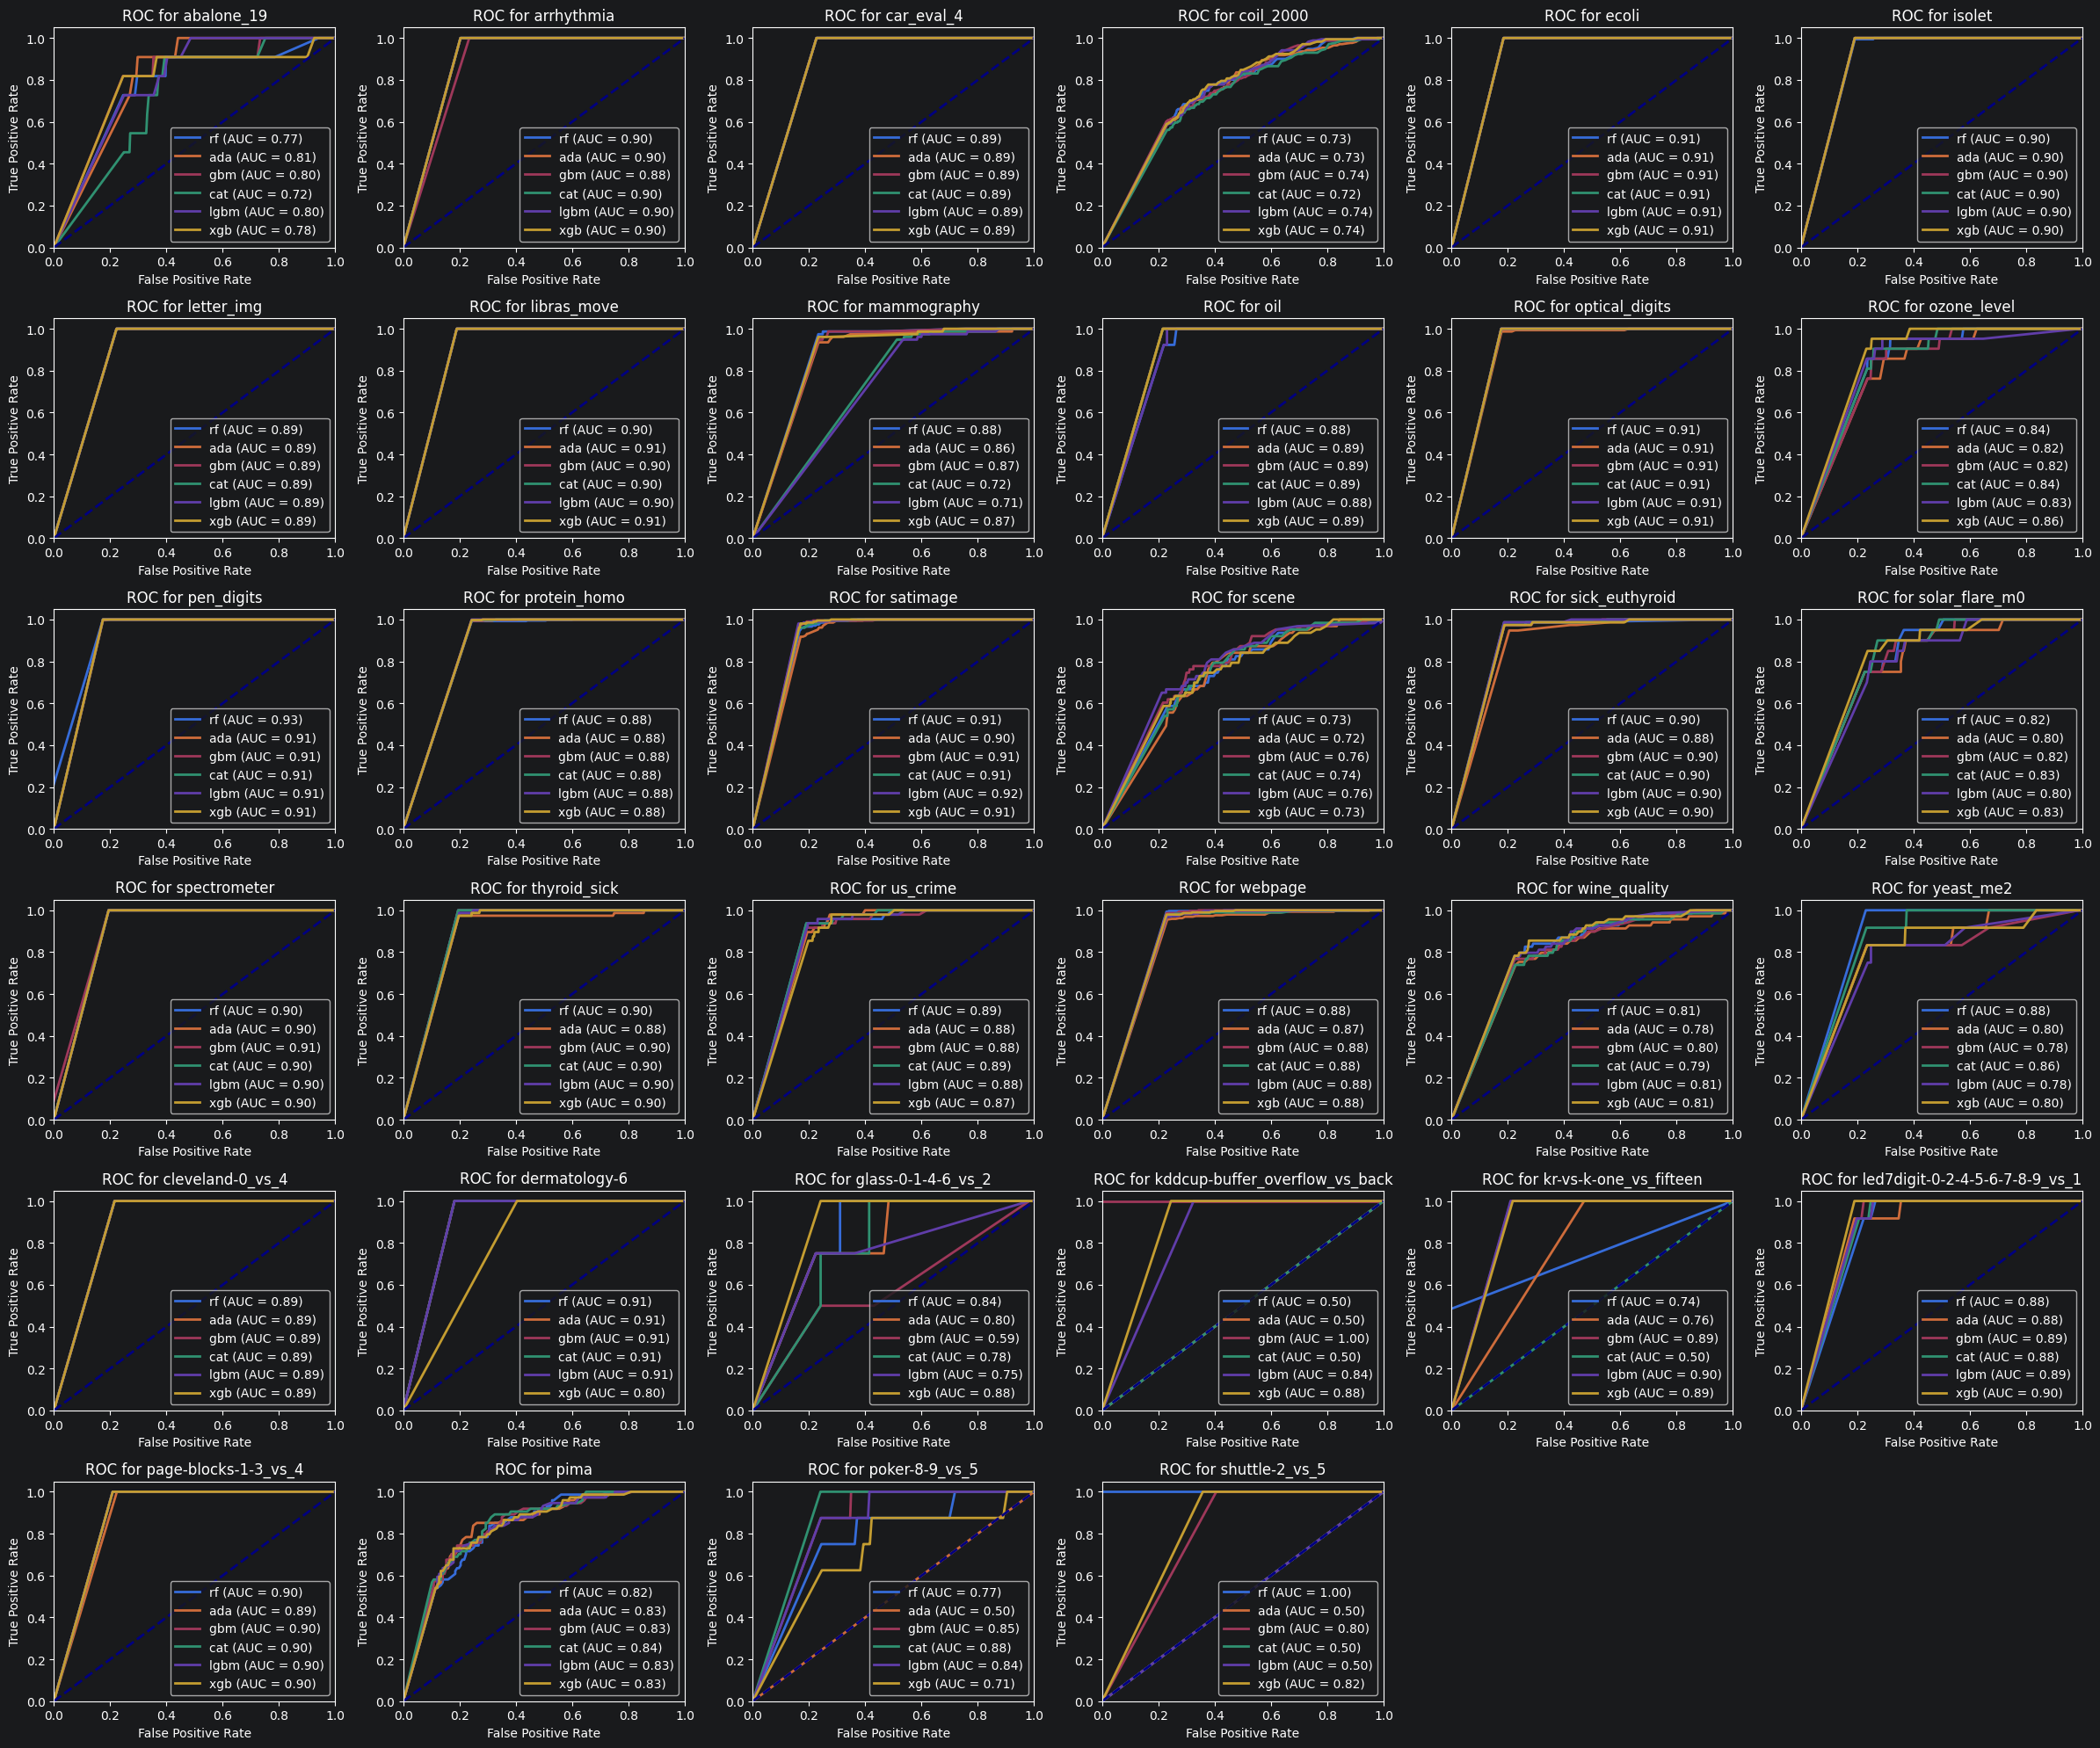

In [12]:
models = [
  "rf", "ada", "gbm", "cat", "lgbm", "xgb",
  ]

# Create figure with 34 subplots
fig, axes = plt.subplots(nrows=6, ncols=6, figsize=(24, 20))  # 6x6 grid for 34 plots (with 2 empty)
axes = axes.ravel()  # Flatten for easy iteration

# Loop through each DataFrame
for i, data in enumerate(scores_dict.keys()):
    ax = axes[i]

    # load data
    X_train, X_test, y_train, y_test = load_dataset(data)
    
    # For each model type
    for estimator in models:
        
        # load model
        search = joblib.load(f"../models/classical/{data}_{estimator}.pkl")

        # obtain probability
        prob = search.predict_proba(X_test)[:, 1]

        # Compute ROC curve
        fpr, tpr, _ =  roc_curve_imbalanced(y_test, prob)
        roc_auc = auc(fpr, tpr)
        
        # Plot ROC curve
        ax.plot(fpr, tpr, lw=2, 
                label=f'{estimator} (AUC = {roc_auc:.2f})')
    
    # Format the plot
    ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC for {data}')
    ax.legend(loc="lower right")

# Hide empty subplots if any
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig('../figures/classic_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

In [14]:
# For the following datasets, the ROC-AUC had a value
# of 1 when calculated with sklearn's function.

# That's because of the probability distribution. That's
# why I use a bespoke ROC-AUC function (evaluate.py)

for data in [
    "dermatology-6", 
    "kddcup-buffer_overflow_vs_back", 
    "kr-vs-k-one_vs_fifteen",
    "shuttle-2_vs_5",
]:
    f = create_df(data)
    print(df[["roc", "roc_std"]])

           roc   roc_std
rf    1.000000  0.000000
ada   0.500000  0.000000
gbm   0.799285  0.007464
cat   0.500000  0.000000
lgbm  0.500000  0.000000
xgb   0.821003  0.004393
           roc   roc_std
rf    1.000000  0.000000
ada   0.500000  0.000000
gbm   0.799285  0.007464
cat   0.500000  0.000000
lgbm  0.500000  0.000000
xgb   0.821003  0.004393
           roc   roc_std
rf    1.000000  0.000000
ada   0.500000  0.000000
gbm   0.799285  0.007464
cat   0.500000  0.000000
lgbm  0.500000  0.000000
xgb   0.821003  0.004393
           roc   roc_std
rf    1.000000  0.000000
ada   0.500000  0.000000
gbm   0.799285  0.007464
cat   0.500000  0.000000
lgbm  0.500000  0.000000
xgb   0.821003  0.004393


## Plot average precision

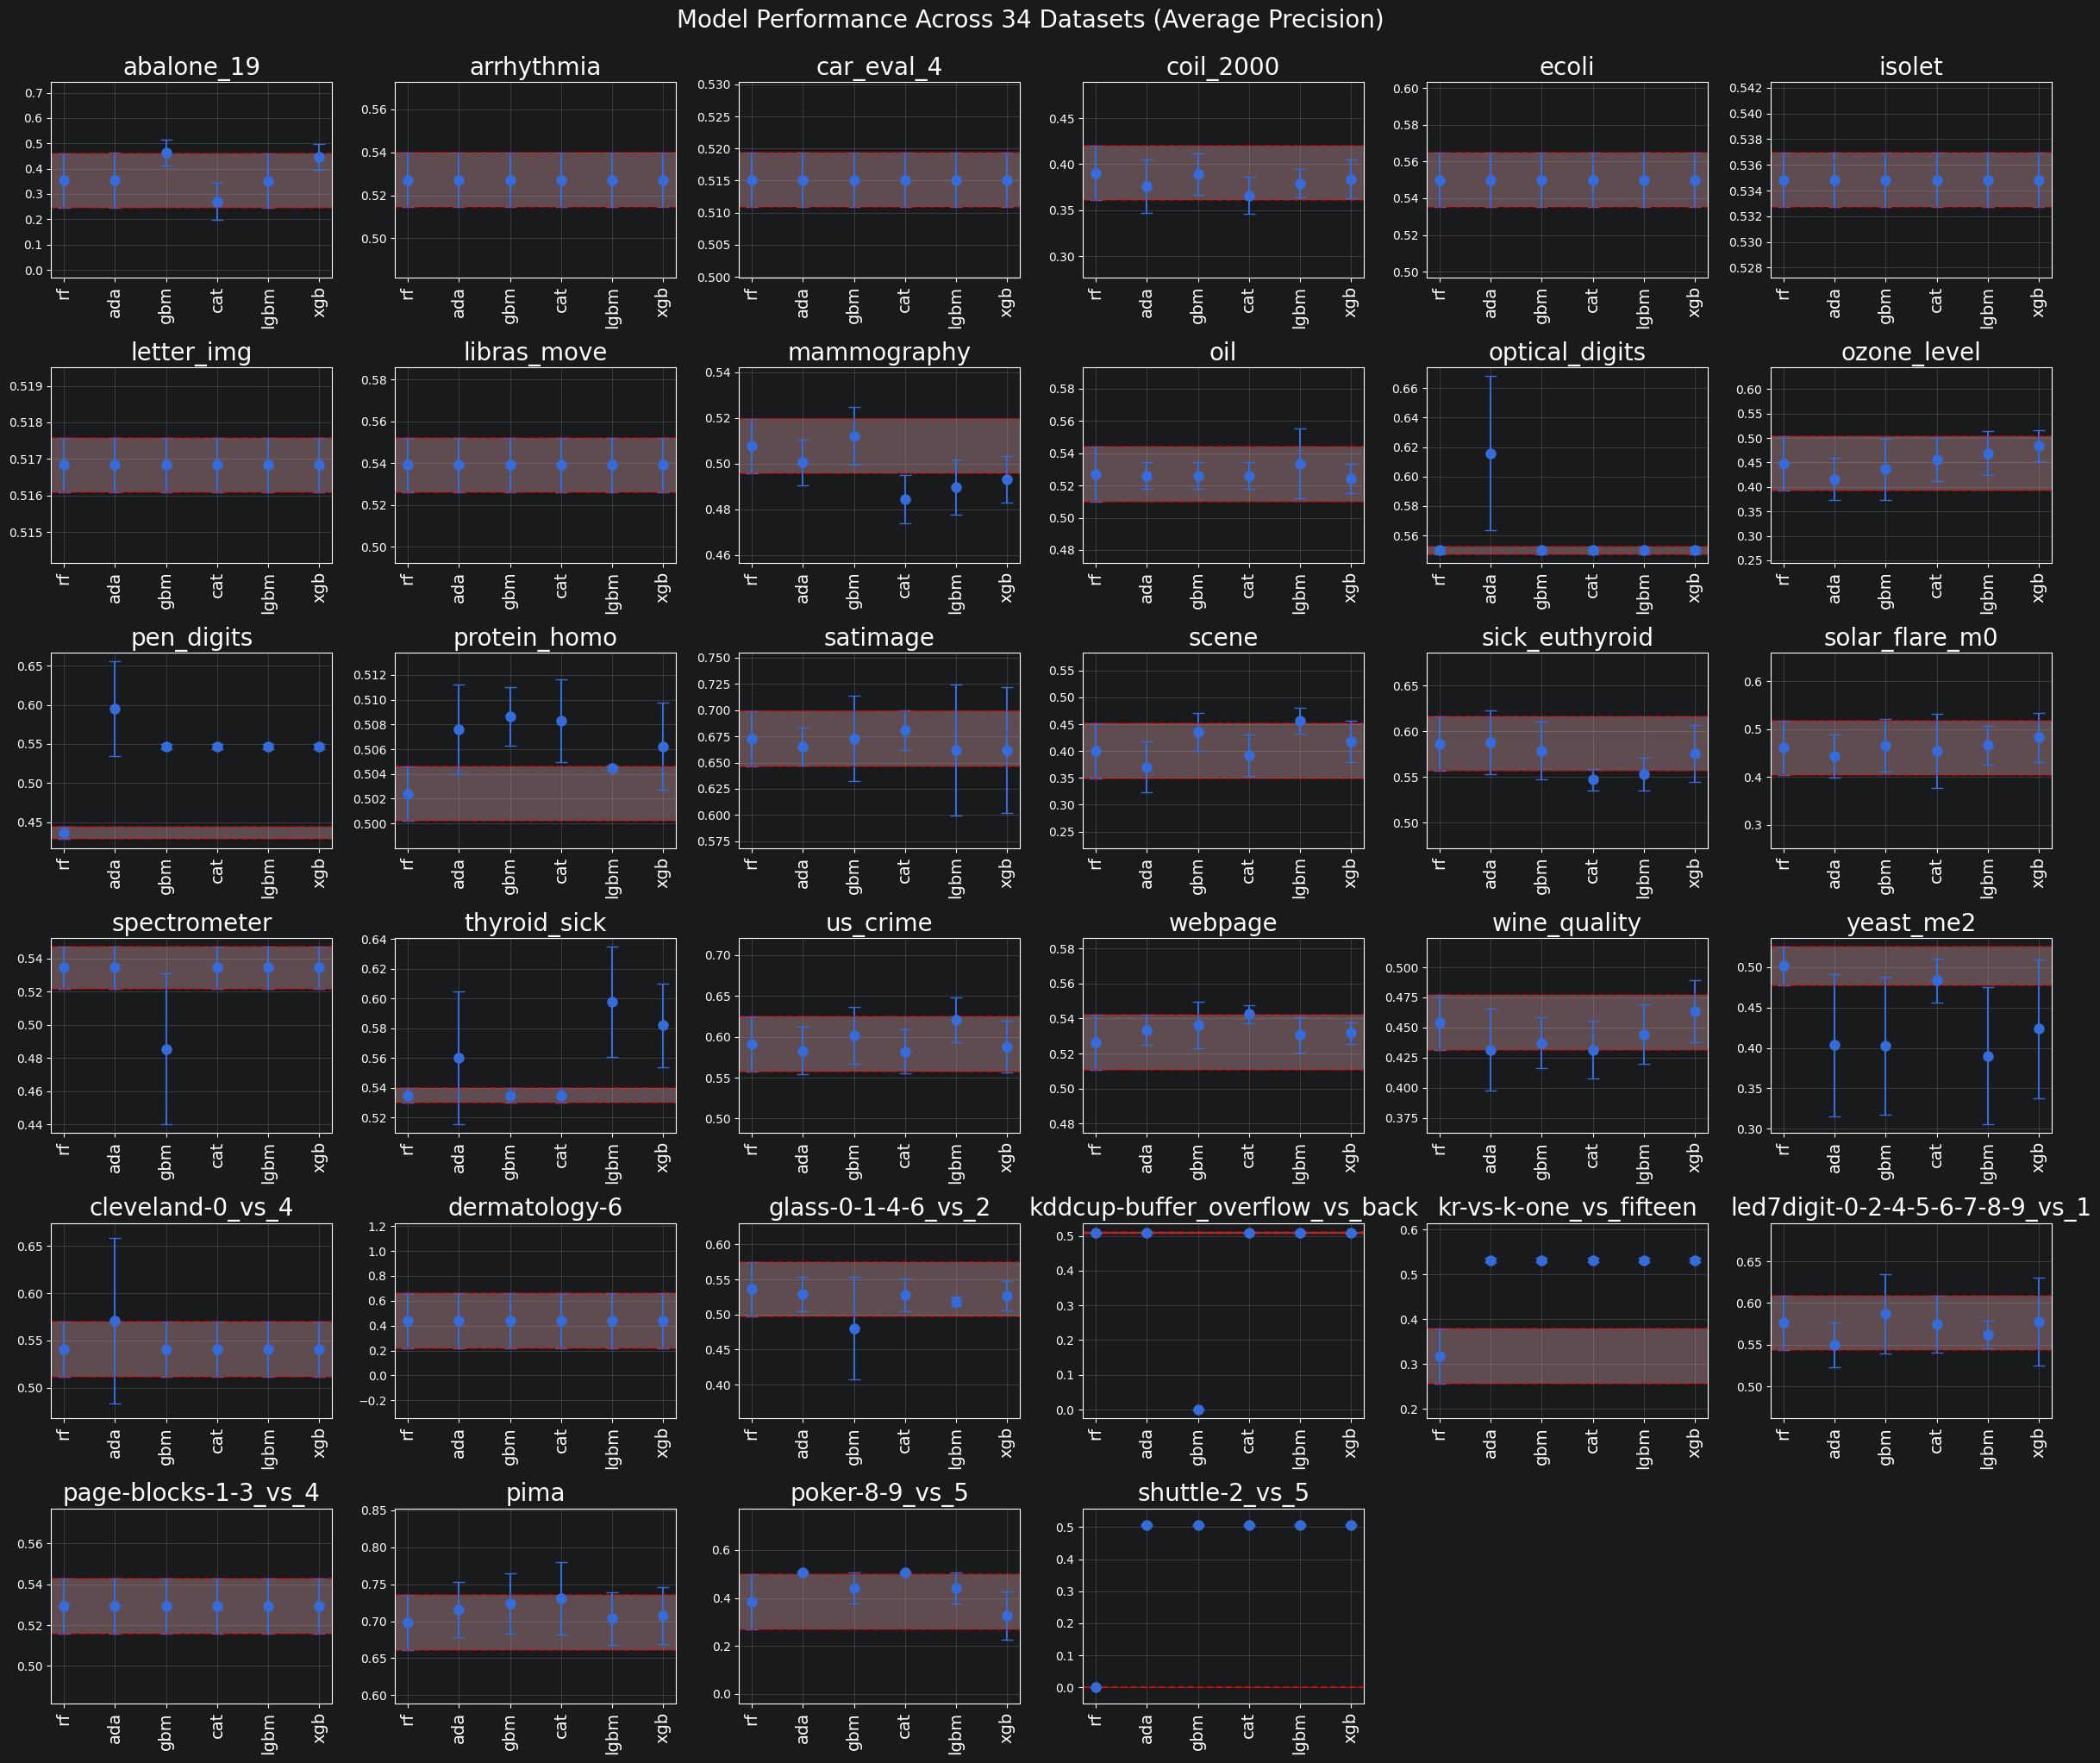

In [15]:
# Create figure with 34 subplots
fig, axes = plt.subplots(nrows=6, ncols=6, figsize=(24, 20))  # 6x6 grid for 34 plots (with 2 empty)
axes = axes.ravel()  # Flatten for easy iteration

# Loop through each DataFrame
for i, data in enumerate(scores_dict.keys()):
    df = create_df(data)
    
    ax = axes[i]
    
    # Extract data
    cls = df.index
    means = df.iloc[:, 2]
    stds = df.iloc[:, 3]

    ref = df.iloc[0, 2]
    upper = df.iloc[0, 2] + df.iloc[0, 3]
    lower = df.iloc[0, 2] - df.iloc[0, 3]
    
    # Create errorbar plot
    ax.errorbar(x=cls, y=means, yerr=stds,
                fmt='o', capsize=5, markersize=8)
    
    # Customize subplot
    ax.set_title(data, fontsize=20)
    ylims = compute_ylim(means, stds, upper, lower)
    ax.set_ylim(ylims)
    ax.tick_params(axis='x', rotation=90, labelsize=14)
    ax.grid(True, alpha=0.3)
    
    # Add horizontal lines at RF error bars:
    ax.axhline(y=upper, color='r', linestyle='--', alpha=0.5)
    ax.axhline(y=lower, color='r', linestyle='--', alpha=0.5)

    # Color area between RF error bars
    ax.axhspan(ymin=lower, ymax=upper, facecolor='pink', alpha=0.3)

# Hide unused subplots
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.suptitle('Model Performance Across 34 Datasets (Average Precision)', fontsize=20, y=1.02)
plt.savefig('../figures/classic_ap.png', dpi=300, bbox_inches='tight')
plt.show()

## Plot PR curves

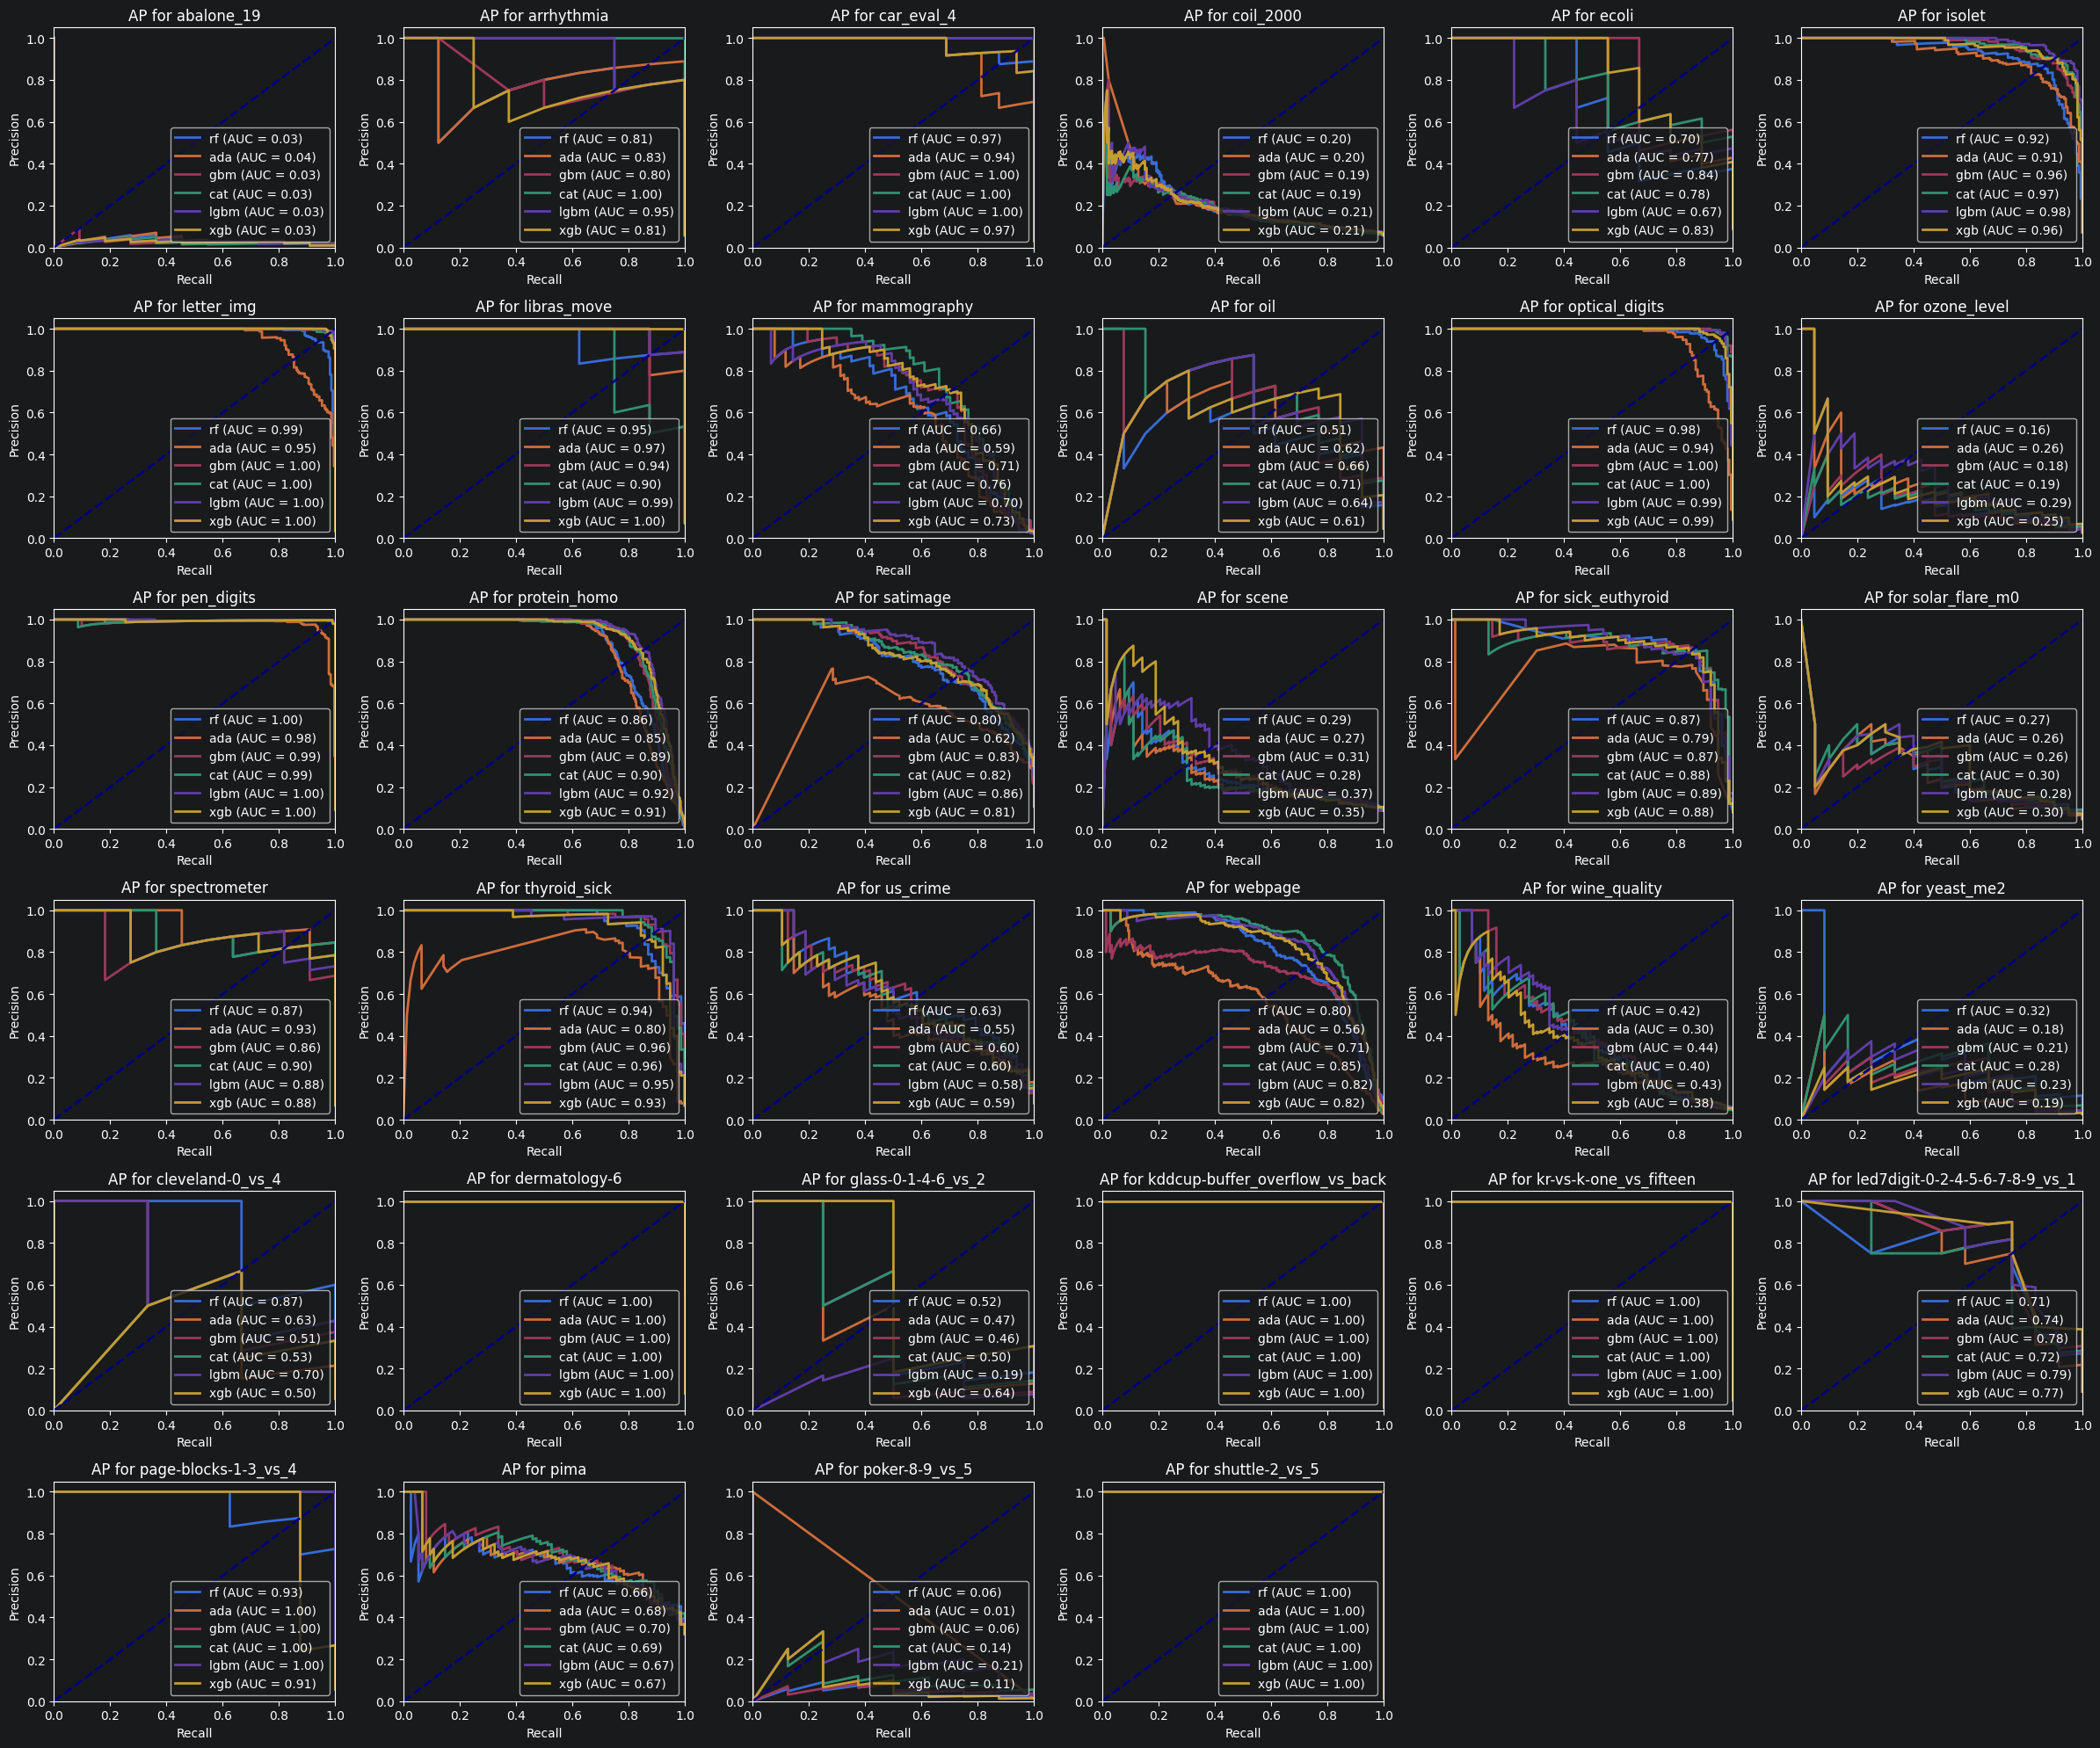

In [18]:
# Create figure with 34 subplots
fig, axes = plt.subplots(nrows=6, ncols=6, figsize=(24, 20))  # 6x6 grid for 34 plots (with 2 empty)
axes = axes.ravel()  # Flatten for easy iteration

# Loop through each DataFrame
for i, data in enumerate(scores_dict.keys()):
    ax = axes[i]

    # load data
    X_train, X_test, y_train, y_test = load_dataset(data)
    
    # For each model type
    for estimator in models:
        
        # load model
        search = joblib.load(f"../models/classical/{data}_{estimator}.pkl")

        # obtain probability
        prob = search.predict_proba(X_test)[:, 1]

        # Compute ROC curve
        precision, recall, _ = precision_recall_curve(y_test, prob)
        ap = average_precision_score(y_test, prob)
        
        # Plot ROC curve
        ax.plot(recall, precision, lw=2, 
                label=f'{estimator} (AUC = {ap:.2f})')
    
    # Format the plot
    ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(f'AP for {data}')
    ax.legend(loc="lower right")

# Hide empty subplots if any
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig('../figures/classic_pr_curves.png', dpi=300, bbox_inches='tight')
plt.show()

## Plot Recall

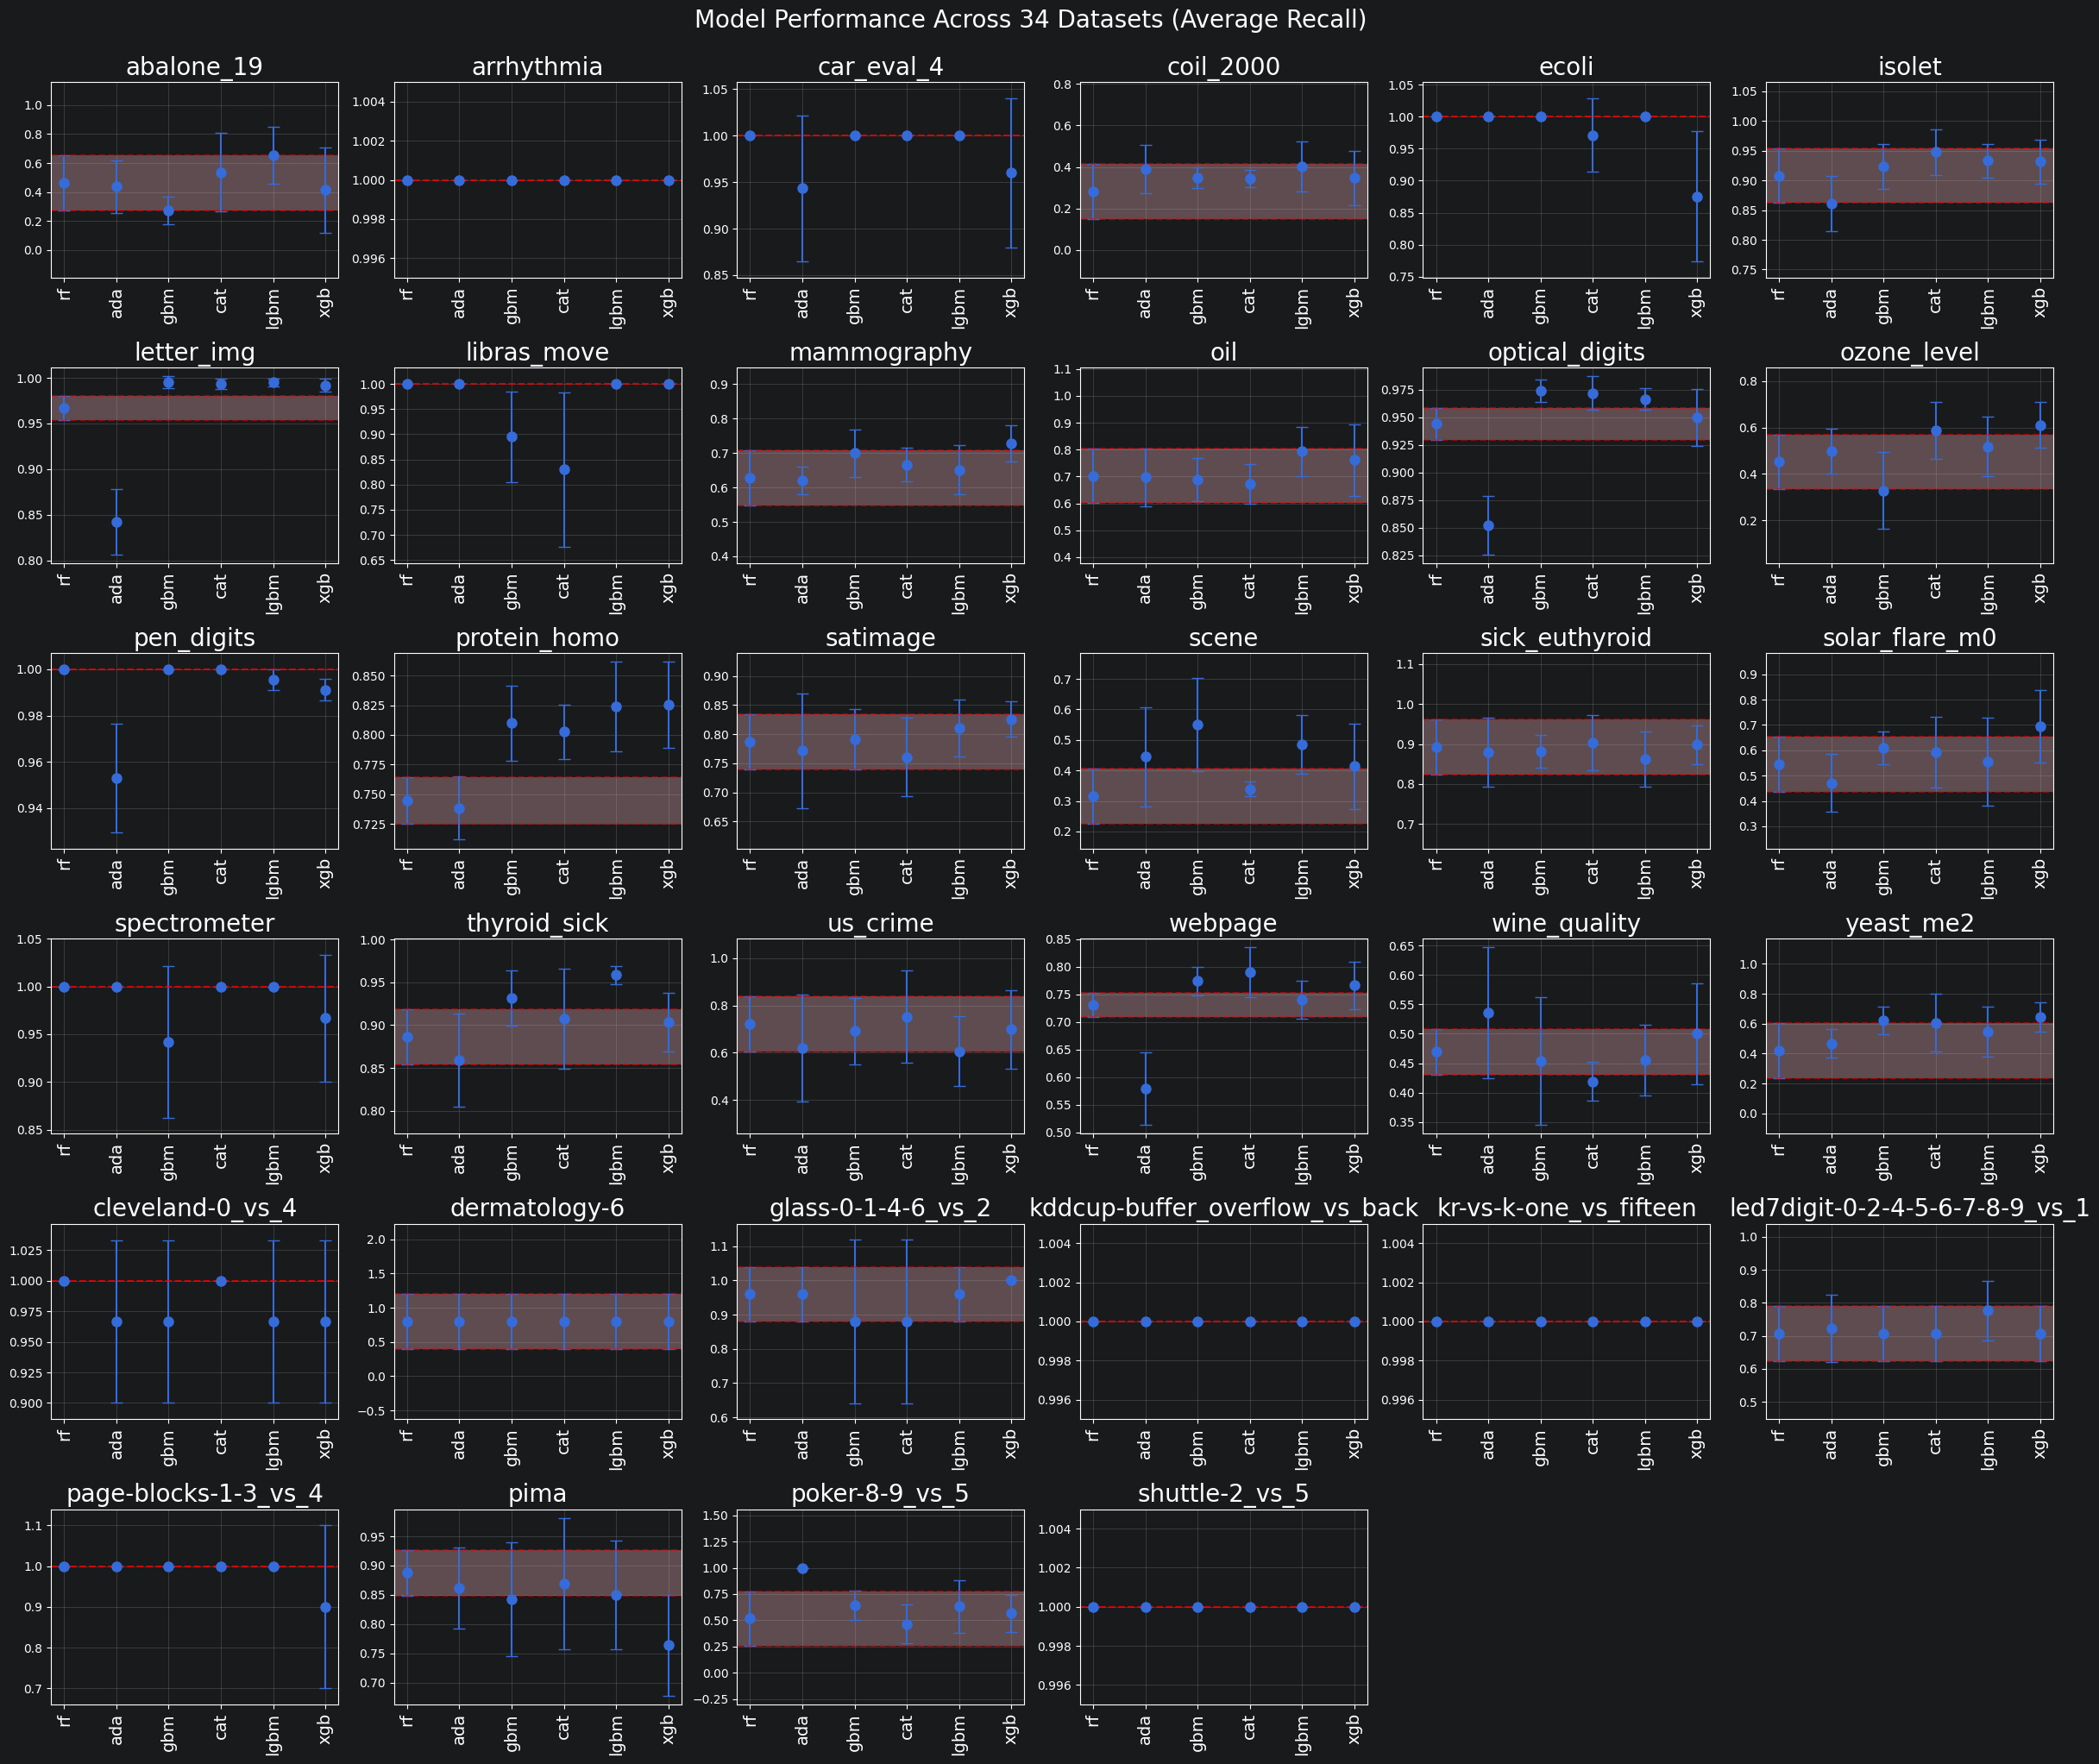

In [19]:
# Create figure with 34 subplots
fig, axes = plt.subplots(nrows=6, ncols=6, figsize=(24, 20))  # 6x6 grid for 34 plots (with 2 empty)
axes = axes.ravel()  # Flatten for easy iteration

# Loop through each DataFrame
for i, data in enumerate(scores_dict.keys()):
    df = create_df(data)
    
    ax = axes[i]
    
    # Extract data
    cls = df.index
    means = df.iloc[:, 6]
    stds = df.iloc[:, 7]

    ref = df.iloc[0, 6]
    upper = df.iloc[0, 6] + df.iloc[0, 7]
    lower = df.iloc[0, 6] - df.iloc[0, 7]
    
    # Create errorbar plot
    ax.errorbar(x=cls, y=means, yerr=stds,
                fmt='o', capsize=5, markersize=8)
    
    # Customize subplot
    ax.set_title(data, fontsize=20)
    ylims = compute_ylim(means, stds, upper, lower)
    ax.set_ylim(ylims)
    ax.tick_params(axis='x', rotation=90, labelsize=14)
    ax.grid(True, alpha=0.3)

    ax.axhline(y=lower, color='r', linestyle='--', alpha=0.5)
    ax.axhline(y=upper, color='r', linestyle='--', alpha=0.5)

    ax.axhspan(ymin=lower, ymax=upper, facecolor='pink', alpha=0.3)

# Hide unused subplots
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.suptitle('Model Performance Across 34 Datasets (Average Recall)', fontsize=20, y=1.02)
plt.savefig('../figures/classic_recall.png', dpi=300, bbox_inches='tight')
plt.show()

## Join datasets and create table

In [20]:
dfs = [create_df(data) for data in scores_dict.keys()]
names = scores_dict.keys()
result = pd.concat(dfs, keys=names, names=['dataset', 'model'])
result

roc   roc_std        ap    ap_std  precision  \
dataset        model                                                      
abalone_19     rf     0.785268  0.080909  0.353421  0.108091   0.051880   
               ada    0.816591  0.042543  0.354178  0.107716   0.059241   
               gbm    0.840827  0.056574  0.463473  0.051102   0.100868   
               cat    0.767958  0.048134  0.270837  0.074185   0.045123   
               lgbm   0.791982  0.056382  0.352535  0.107894   0.034522   
...                        ...       ...       ...       ...        ...   
shuttle-2_vs_5 ada    0.500000  0.000000  0.506365  0.001641   1.000000   
               gbm    0.799285  0.007464  0.506365  0.001641   1.000000   
               cat    0.500000  0.000000  0.506365  0.001641   1.000000   
               lgbm   0.500000  0.000000  0.506365  0.001641   1.000000   
               xgb    0.821003  0.004393  0.506365  0.001641   1.000000   

                      precision_std    recall  recall_std    thresh  \
dataset        model                                                  
abalone_19     rf          0.033888  0.462381    0.188841  0.028288   
               ada         0.027737  0.437619    0.182166  0.437323   
               gbm         0.061182  0.275714    0.094837  0.012380   
               cat         0.021664  0.535714    0.270843  0.018867   
               lgbm        0.018917  0.652381    0.197260  0.014374   
...                             ...       ...         ...       ...   
shuttle-2_vs_5 ada         0.000000  1.000000    0.000000  0.880797   
               gbm         0.000000  1.000000    0.000000  1.000000   
               cat         0.000000  1.000000    0.000000  0.995891   
               lgbm        0.000000  1.000000    0.000000  1.000000   
               xgb         0.000000  1.000000    0.000000  0.964692   

                         tresh_std  
dataset        model                
abalone_19     rf     1.289234e-02  
               ada    5.169671e-03  
               gbm    1.213026e-02  
               cat    1.005403e-02  
               lgbm   6.381535e-03  
...                            ...  
shuttle-2_vs_5 ada    1.110223e-16  
               gbm    6.949545e-11  
               cat    1.849390e-03  
               lgbm   1.110223e-16  
               xgb    0.000000e+00  

[204 rows x 10 columns]

In [21]:
result['roc_±_std'] = result['roc'].round(3).astype(str) + '±' + result['roc_std'].round(3).astype(str)
result['ap_±_std'] = result['ap'].round(3).astype(str) + '±' + result['ap_std'].round(3).astype(str)
result['recall_±_std'] = result['recall'].round(3).astype(str) + '±' + result['recall_std'].round(3).astype(str)
result['thresh_±_std'] = result['thresh'].round(3).astype(str) + '±' + result['tresh_std'].round(3).astype(str)

result.to_csv('../results/classic_models_performance.csv', index=True)

result[['roc_±_std', 'ap_±_std', 'recall_±_std', 'thresh_±_std']]

roc_±_std     ap_±_std recall_±_std thresh_±_std
dataset        model                                                    
abalone_19     rf     0.785±0.081  0.353±0.108  0.462±0.189  0.028±0.013
               ada    0.817±0.043  0.354±0.108  0.438±0.182  0.437±0.005
               gbm    0.841±0.057  0.463±0.051  0.276±0.095  0.012±0.012
               cat    0.768±0.048  0.271±0.074  0.536±0.271   0.019±0.01
               lgbm   0.792±0.056  0.353±0.108  0.652±0.197  0.014±0.006
...                           ...          ...          ...          ...
shuttle-2_vs_5 ada        0.5±0.0  0.506±0.002      1.0±0.0    0.881±0.0
               gbm    0.799±0.007  0.506±0.002      1.0±0.0      1.0±0.0
               cat        0.5±0.0  0.506±0.002      1.0±0.0  0.996±0.002
               lgbm       0.5±0.0  0.506±0.002      1.0±0.0      1.0±0.0
               xgb    0.821±0.004  0.506±0.002      1.0±0.0    0.965±0.0

[204 rows x 4 columns]